In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect

In [2]:
# Cargar datos oficiales
ruta_origen = os.path.join("..", 'Data', 'INEViajeroOrigenClean11022026.csv')
origen = pd.read_csv(ruta_origen)

ruta_destino = os.path.join("..", 'Data', 'INEViajeroDestinoClean11022026.csv')
destino = pd.read_csv(ruta_destino)

In [3]:
# Cargar datos internos version 02022026
ruta_interno = os.path.join("..", 'Data', 'TouristAccommodationClean02022026.csv')
interno = pd.read_csv(ruta_interno)

# solo comparamos los datos internos más recientes: en el año 2021
interno = interno[interno['insert_date'].str.contains('2021')]

## Origen de viajeros

In [ ]:
#origen[origen['origen'] != 'El Extranjero'].groupby('origen').agg(viajeros=('viajeros', 'sum')).sort_values(by = 'viajeros', ascending=False).reset_index()
#origen.groupby('origen').agg(viajeros=('viajeros', 'sum')).sort_values(by = 'viajeros', ascending=False).reset_index()
#origen[origen['origen'] != 'El Extranjero'].groupby('pais').agg(viajeros=('viajeros', 'sum')).sort_values(by = 'viajeros', ascending=False).reset_index()

## Nivel internacional de demanda: Destino de viajeros

In [5]:
destino[destino['origen'] == 'El Extranjero'].groupby(['provincia']).agg(viajeros=('viajeros', 'sum')).sort_values(by = 'viajeros', ascending=False).reset_index().head(5)

,provincia,viajeros
0,"Balears, Illes",13123914
1,Barcelona,10820394
2,Madrid,6644650
3,"Palmas, Las",6456195
4,Málaga,4533494


In [6]:
destino[destino['origen'] == 'España'].groupby(['provincia']).agg(viajeros=('viajeros', 'sum')).sort_values(by = 'viajeros', ascending=False).reset_index().head(5)

,provincia,viajeros
0,Madrid,10681255
1,Barcelona,5602973
2,Málaga,4533499
3,Alicante/Alacant,4390778
4,Valencia/València,3519829


In [4]:
# crear una tabla de proporcion de viajeros extranjeros en cada provincia

# 1. agroupar y pivotar datos
viajero = destino.groupby(['origen', 'provincia']).agg(viajeros=('viajeros', 'sum')).reset_index().pivot(
    index='provincia', columns='origen', values='viajeros'
).reset_index().rename_axis(None, axis=1)

# 2. Calcular el porcentaje como valor numérico (0.15 en lugar de "15%")
viajero['viajero_extrajero'] =  (viajero['El Extranjero'] / (viajero['El Extranjero'] + viajero['España']))

# 3. Ordenar por la columna numérica
viajero = viajero.sort_values(by='viajero_extrajero', ascending=False)

# 4. Crear la columna de formato solo para visualización
#viajero['viajero_extrajero'] = viajero['viajero_extrajero'].map('{:.0%}'.format)

# 5. Eliminando columnas auxiliares
viajero = viajero.drop(columns=['El Extranjero', 'España'])

viajero.head(5)

,provincia,viajero_extrajero
6,"Balears, Illes",0.824885
34,"Palmas, Las",0.740511
38,Santa Cruz de Tenerife,0.671317
7,Barcelona,0.658841
30,Málaga,0.500000


## Nivel internacional de oferta de servicios: Idiomas extranjeros en anuncios

In [7]:
# Definir una funcion para detectar el idioma de un texto
def det(x):
    try:
        lang = detect(x)
    except:
        lang = np.nan
    return lang


# Aplicar la funcion para detectar los idiomas de la columna "description" de cada alojamiento
interno['language'] = interno['description'].apply(lambda x: det(x))

interno['language'].unique()

array(['en', 'es', 'pt', 'fr', 'de', 'ca', 'nl', nan], dtype=object)

In [8]:
# Ver los nombres completos de los idiomas
language_map = {
    'en': 'English',
    'es': 'Spanish',
    'fr': 'French',
    'de': 'German',
    'ca': 'Catalan',
    'pt': 'Portuguese',
    'nl': 'Dutch'}

interno['language_full'] = interno['language'].map(language_map)

In [9]:
# Porporcion de idiomas internacionales en los anuncios por ciudad/provincia, para indicar el nivel internacional
idioma = interno['language_full'].apply(lambda x: x not in ['Spanish', 'Catalan']).groupby(interno['city']).mean().reset_index(name='idioma_extranjero')
idioma

,city,idioma_extranjero
0,Barcelona,0.731092
1,Girona,0.627907
2,Madrid,0.435714
3,Malaga,0.531250
4,Mallorca,0.863636
5,Menorca,0.571429
6,Sevilla,0.468750
7,Valencia,0.380952


## Comparar nivel internacional de viajeros (demanda) y idiomas de anuncios (oferta)

In [ ]:
# crear una columna de provincia a la tabla idioma para juntar con la tabla viajero
province_map = {
    'Barcelona': 'Barcelona',
    'Girona': 'Girona',
    'Madrid': 'Madrid',
    'Malaga': 'Málaga',
    'Mallorca': 'Balears, Illes',
    'Menorca': 'Balears, Illes',
    'Sevilla': 'Sevilla',
    'Valencia': 'Valencia/València'
}

idioma['provincia'] = idioma['city'].map(province_map)

In [11]:
# juntar tablas y transformar para visualizacion

internacional = pd.merge(idioma, viajero, on='provincia', how = 'inner').drop(columns = 'provincia')

internacional['brecha'] = internacional['idioma_extranjero'] - internacional['viajero_extrajero']
internacional['brecha'] = (internacional['brecha'] * 100).round(0).astype(np.int64)

internacional = pd.melt(internacional, id_vars=['city', 'brecha'], value_vars=['idioma_extranjero', 'viajero_extrajero'])

internacional = internacional.rename(columns = {'variable': 'extranjero',
                                                "value": "porcentaje"})

internacional['extranjero'] = internacional['extranjero'].str.replace('idioma_extranjero', 'Idiomas extranjeros en anuncio')
internacional['extranjero'] = internacional['extranjero'].str.replace('viajero_extrajero', 'Viajeros extranjeros de visita')

internacional['porcentaje'] = (internacional['porcentaje'] * 100).round(0).astype(np.int64)

internacional['brecha_cat'] = internacional['brecha'].apply(lambda x: 'positivo' if x > 0 else 'negativo')

internacional = internacional.sort_values(by='brecha')

internacional

,city,brecha,extranjero,porcentaje,brecha_cat
5,Menorca,-25,Idiomas extranjeros en anuncio,57,negativo
13,Menorca,-25,Viajeros extranjeros de visita,82,negativo
15,Valencia,2,Viajeros extranjeros de visita,36,positivo
7,Valencia,2,Idiomas extranjeros en anuncio,38,positivo
3,Malaga,3,Idiomas extranjeros en anuncio,53,positivo
11,Malaga,3,Viajeros extranjeros de visita,50,positivo
12,Mallorca,4,Viajeros extranjeros de visita,82,positivo
4,Mallorca,4,Idiomas extranjeros en anuncio,86,positivo
10,Madrid,5,Viajeros extranjeros de visita,38,positivo
2,Madrid,5,Idiomas extranjeros en anuncio,44,positivo


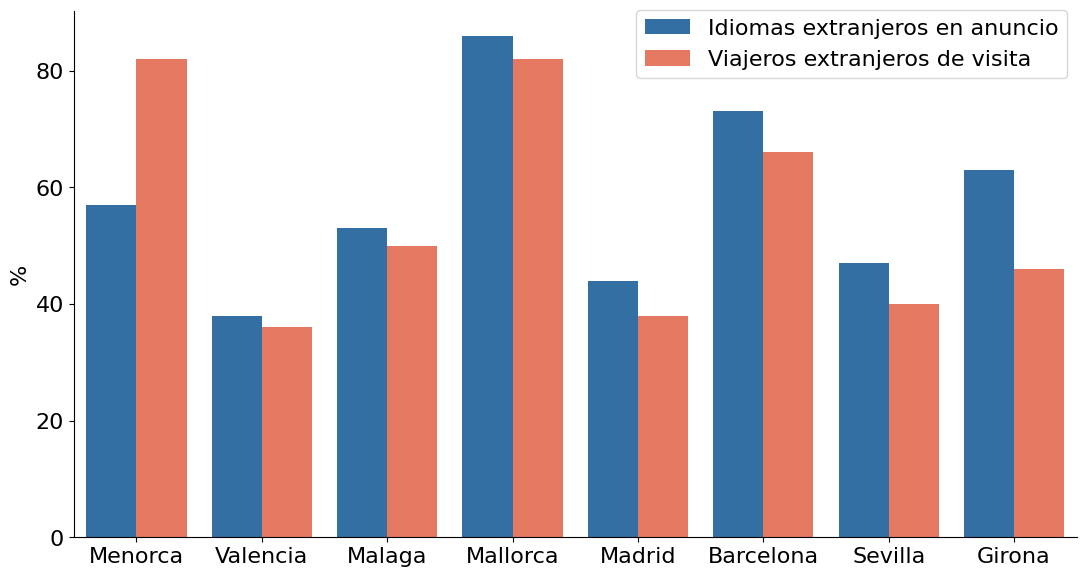

In [12]:
# grafico que muestra % Idiomas extranjeros en anuncio (oferta) y % Viajeros extranjeros de visita (demanda)

sns.catplot(data = internacional,
            kind = "bar",
            x = "city",
            y = "porcentaje",
            hue = "extranjero",
            palette = ['#2171b5', '#fb6a4a'],
            legend_out = False,
            height=6, aspect=1.8
            )


plt.title('')
plt.xlabel('')
plt.ylabel('%', fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(fontsize = 16, bbox_to_anchor=(0.55, 0.85)).set_title("")
plt.show()

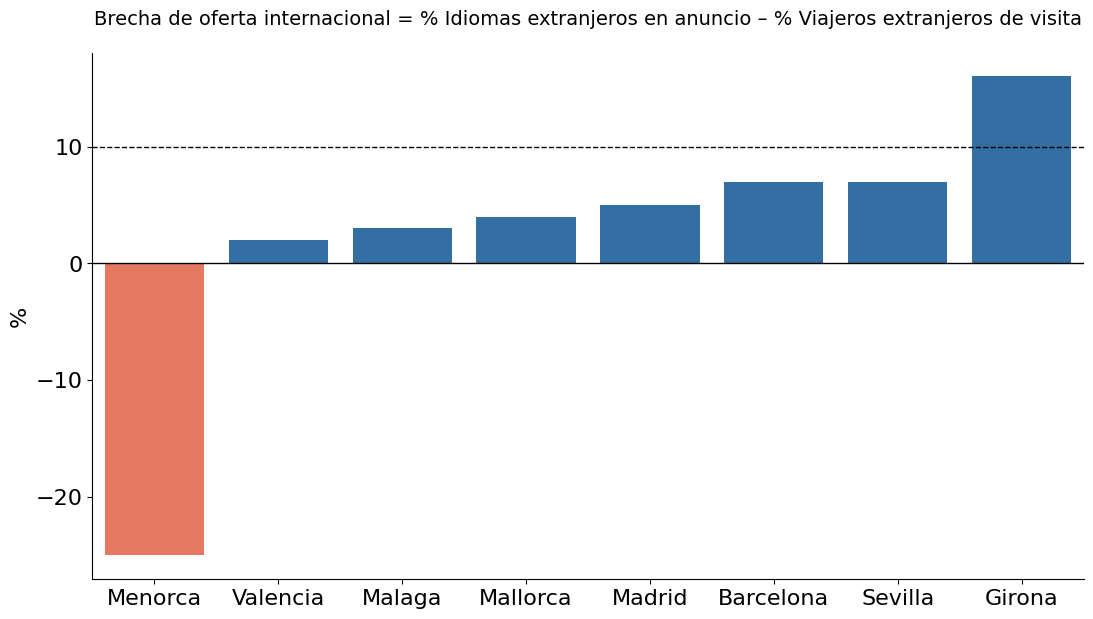

In [13]:
# grafico que muestra las brechas de oferta de servicios internacionales
# Brecha de oferta internacional = % Idiomas extranjeros en anuncio – % Viajeros extranjeros de visita

g = sns.catplot(data = internacional,
            kind = "bar",
            x = "city",
            y = "brecha",
            hue = "brecha_cat",
            palette = ['#fb6a4a', '#2171b5'],
            legend_out = False,
            height=6, aspect=1.8
            )

# Añadir lineas horizontales
# zorder=0 para asegurar que las lineas estén atrás de las barras
g.ax.axhline(0, color='black', lw=1) 
g.ax.axhline(10, color='black', ls='--', lw=1)

# formatos del grafico
plt.title('Brecha de oferta internacional = % Idiomas extranjeros en anuncio – % Viajeros extranjeros de visita',
          fontsize = 14, pad = 20)
plt.xlabel('')
plt.ylabel('%', fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

# eliminar el lengend
if g._legend:
    g._legend.remove()

plt.show()